# Noise proxy — $\widehat{E}\epsilon^2$

Proxy from fifth-best (all-sample) RV structure. Empirics: Pass 1 ETH panel + Pass 2.6 blocker noise_std joins.


In [1]:
from pathlib import Path
import json
import math
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

BOOK = Path('/home/dev/srv/ares-microstructure/research/books/mn_tuwrv')
OUT = BOOK / 'out'
FIGS = OUT / 'desk_synthesis' / 'figs'
sys.path.insert(0, str(BOOK.parents[2]))  # research/

def jload(rel):
    return json.loads((OUT / rel).read_text())

def show_fig(name, caption=None):
    p = FIGS / name
    if caption:
        display(Markdown(f'**{caption}** — `{p.relative_to(BOOK)}`'))
    if p.exists():
        display(Image(filename=str(p)))
    else:
        display(Markdown(f'*missing figure* `{p}` — run `scripts/build_notebook_figs.py`'))

bc = jload('blocker_close/blocker_close.json')
gc = jload('gap_close/gap_close.json')
mc = jload('monte_carlo/mc_summary.json')
p2 = jload('pass2/pass2_gates.json')
print('BOOK', BOOK)
print('figs', sorted(p.name for p in FIGS.glob('*.png')))


BOOK /home/dev/srv/ares-microstructure/research/books/mn_tuwrv
figs ['fig_clock_medians.png', 'fig_gate_counts.png', 'fig_mc_rmse_ladder.png', 'fig_mid_venue_split.png', 'fig_noise_vs_spread.png', 'fig_noise_vs_spread_gap_close.png', 'fig_ratio_hist.png', 'fig_tob_coverage.png', 'fig_tsrv_oos.png', 'signal_board.png']


panel meta {'symbol': 'ETH', 'days': ['2026-09-28', '2026-09-29', '2026-09-30'], 'K': 300, 'step': 300, 'dt_s': 1.0} n_ok 9


,day,venue,noise_std,first_adj,fifth_over_fourth
0,2026-09-28,hyperliquid,0.000034,NaN,1.055179
1,2026-09-28,deribit,0.000034,NaN,1.227472
2,2026-09-28,kraken,0.000035,NaN,1.095047
3,2026-09-29,hyperliquid,0.000028,NaN,0.854094
4,2026-09-29,deribit,0.000039,NaN,0.938737
5,2026-09-29,kraken,0.000034,NaN,1.291338
6,2026-09-30,hyperliquid,0.000051,NaN,0.819374
7,2026-09-30,deribit,0.000058,NaN,1.019043
8,2026-09-30,kraken,0.000056,NaN,0.979961


,noise_std,first_adj,fifth_over_fourth
count,9.000000,0.0,9.000000
mean,0.000041,NaN,1.031138
std,0.000011,NaN,0.157482
min,0.000028,NaN,0.819374
25%,0.000034,NaN,0.938737
50%,0.000035,NaN,1.019043
75%,0.000051,NaN,1.095047
max,0.000058,NaN,1.291338


blocker noise_std n 90


,count,mean,std,min,25%,50%,75%,max
venue,,,,,,,,
deribit,42.0,0.000045,0.000017,0.000019,0.000032,0.000044,0.000055,0.000088
hyperliquid,42.0,0.000041,0.000021,0.000009,0.000024,0.000038,0.000053,0.000105
kraken,6.0,0.000032,0.000006,0.000025,0.000028,0.000034,0.000035,0.000039


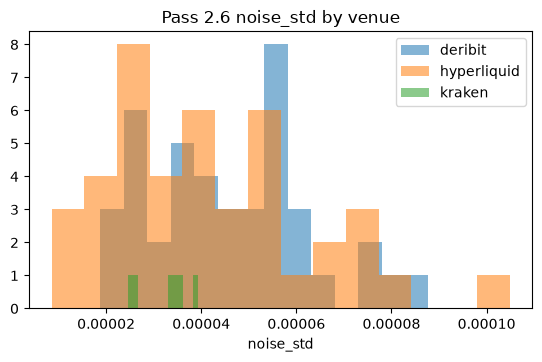

# Noise proxy — EXP_REPORT (Pass 2.5)

- Multi-week n_ok=68
- Calendar / trade / tick_bounce / mid gates: {'calendar': 'Kill', 'trade': 'Kill', 'tick_bounce': 'Kill', 'mid': 'Hold'}
- `cont.noise_var_fifth` remains **Hold** (liquidity proxy; not efficiency).



In [2]:
panel = jload('tsrv_panel/panel_eth.json')
rows = [r for r in panel['rows'] if r.get('ok')]
print('panel meta', panel['meta'], 'n_ok', len(rows))
if rows:
    df = pd.DataFrame([
        {
            'day': r.get('day'), 'venue': r.get('venue'),
            'noise_std': float(r.get('noise_std') or r.get('calendar',{}).get('noise_std') or np.nan),
            'first_adj': float(r.get('first_adj') or r.get('calendar',{}).get('first_adj') or np.nan),
            'fifth_over_fourth': float(r.get('fifth_over_fourth') or r.get('calendar',{}).get('fifth_over_fourth') or np.nan),
        }
        for r in rows
    ])
    display(df)
    display(df.select_dtypes(include=[np.number]).describe())

# blocker noise_std distribution if present via calendar
brows = [r for r in bc['rows'] if r.get('ok')]
ns = []
for r in brows:
    cal = r.get('calendar') or {}
    if np.isfinite(cal.get('noise_std', np.nan)):
        ns.append({'venue': r['venue'], 'day': r['day'], 'symbol': r['symbol'], 'noise_std': float(cal['noise_std'])})
bdf = pd.DataFrame(ns)
print('blocker noise_std n', len(bdf))
if len(bdf):
    display(bdf.groupby('venue')['noise_std'].describe())
    fig, ax = plt.subplots(figsize=(6.5,3.6))
    for v, g in bdf.groupby('venue'):
        ax.hist(g['noise_std'].astype(float), bins=14, alpha=0.55, label=v)
    ax.set_xlabel('noise_std'); ax.legend(); ax.set_title('Pass 2.6 noise_std by venue')
    plt.show()
print((BOOK/'chapters/noise_proxy/EXP_REPORT.md').read_text()[:1200])
